In [6]:
# -*- coding: utf-8 -*-
import json

# ===================== 你的固定路径（已直接填入）=====================
INPUT_IPYNB = "/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260401/test_260401_spaMMCL.ipynb"
OUTPUT_PY = INPUT_IPYNB.replace(".ipynb", ".py")
# ====================================================================

def extract_notebook_code():
    try:
        # 读取ipynb文件（JSON格式）
        with open(INPUT_IPYNB, 'r', encoding='utf-8') as f:
            notebook = json.load(f)

        all_code = []
        # 遍历所有单元格，只提取代码
        for cell in notebook["cells"]:
            if cell["cell_type"] == "code":
                # 按原始顺序拼接代码
                code = "".join(cell["source"])
                all_code.append(code)

        # 写入新的py文件
        with open(OUTPUT_PY, 'w', encoding='utf-8') as f:
            f.write("# 自动提取自 Jupyter Notebook\n")
            f.write(f"# 源文件：{INPUT_IPYNB}\n\n")
            f.write("\n\n".join(all_code))

        print(f"✅ 提取完成！")
        print(f"📄 源文件：{INPUT_IPYNB}")
        print(f"💾 生成文件：{OUTPUT_PY}")

    except FileNotFoundError:
        print("❌ 错误：未找到指定的ipynb文件，请检查路径")
    except Exception as e:
        print(f"❌ 出错了：{str(e)}")

if __name__ == "__main__":
    # 修正：正确的函数名
    extract_notebook_code()

✅ 提取完成！
📄 源文件：/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260401/test_260401_spaMMCL.ipynb
💾 生成文件：/home/zhangjunyi/xiangmu/nichecompass-main/TuMeNiche/src/my/test_260401/test_260401_spaMMCL.py


=== 病理注释类型及数量统计 ===
tumor&stroma                   651
tumor                          627
stroma_fibroblastic_IC med     288
stroma_fibroblastic_IC high    236
NaN                              1
Name: pathology_annotation, dtype: int64


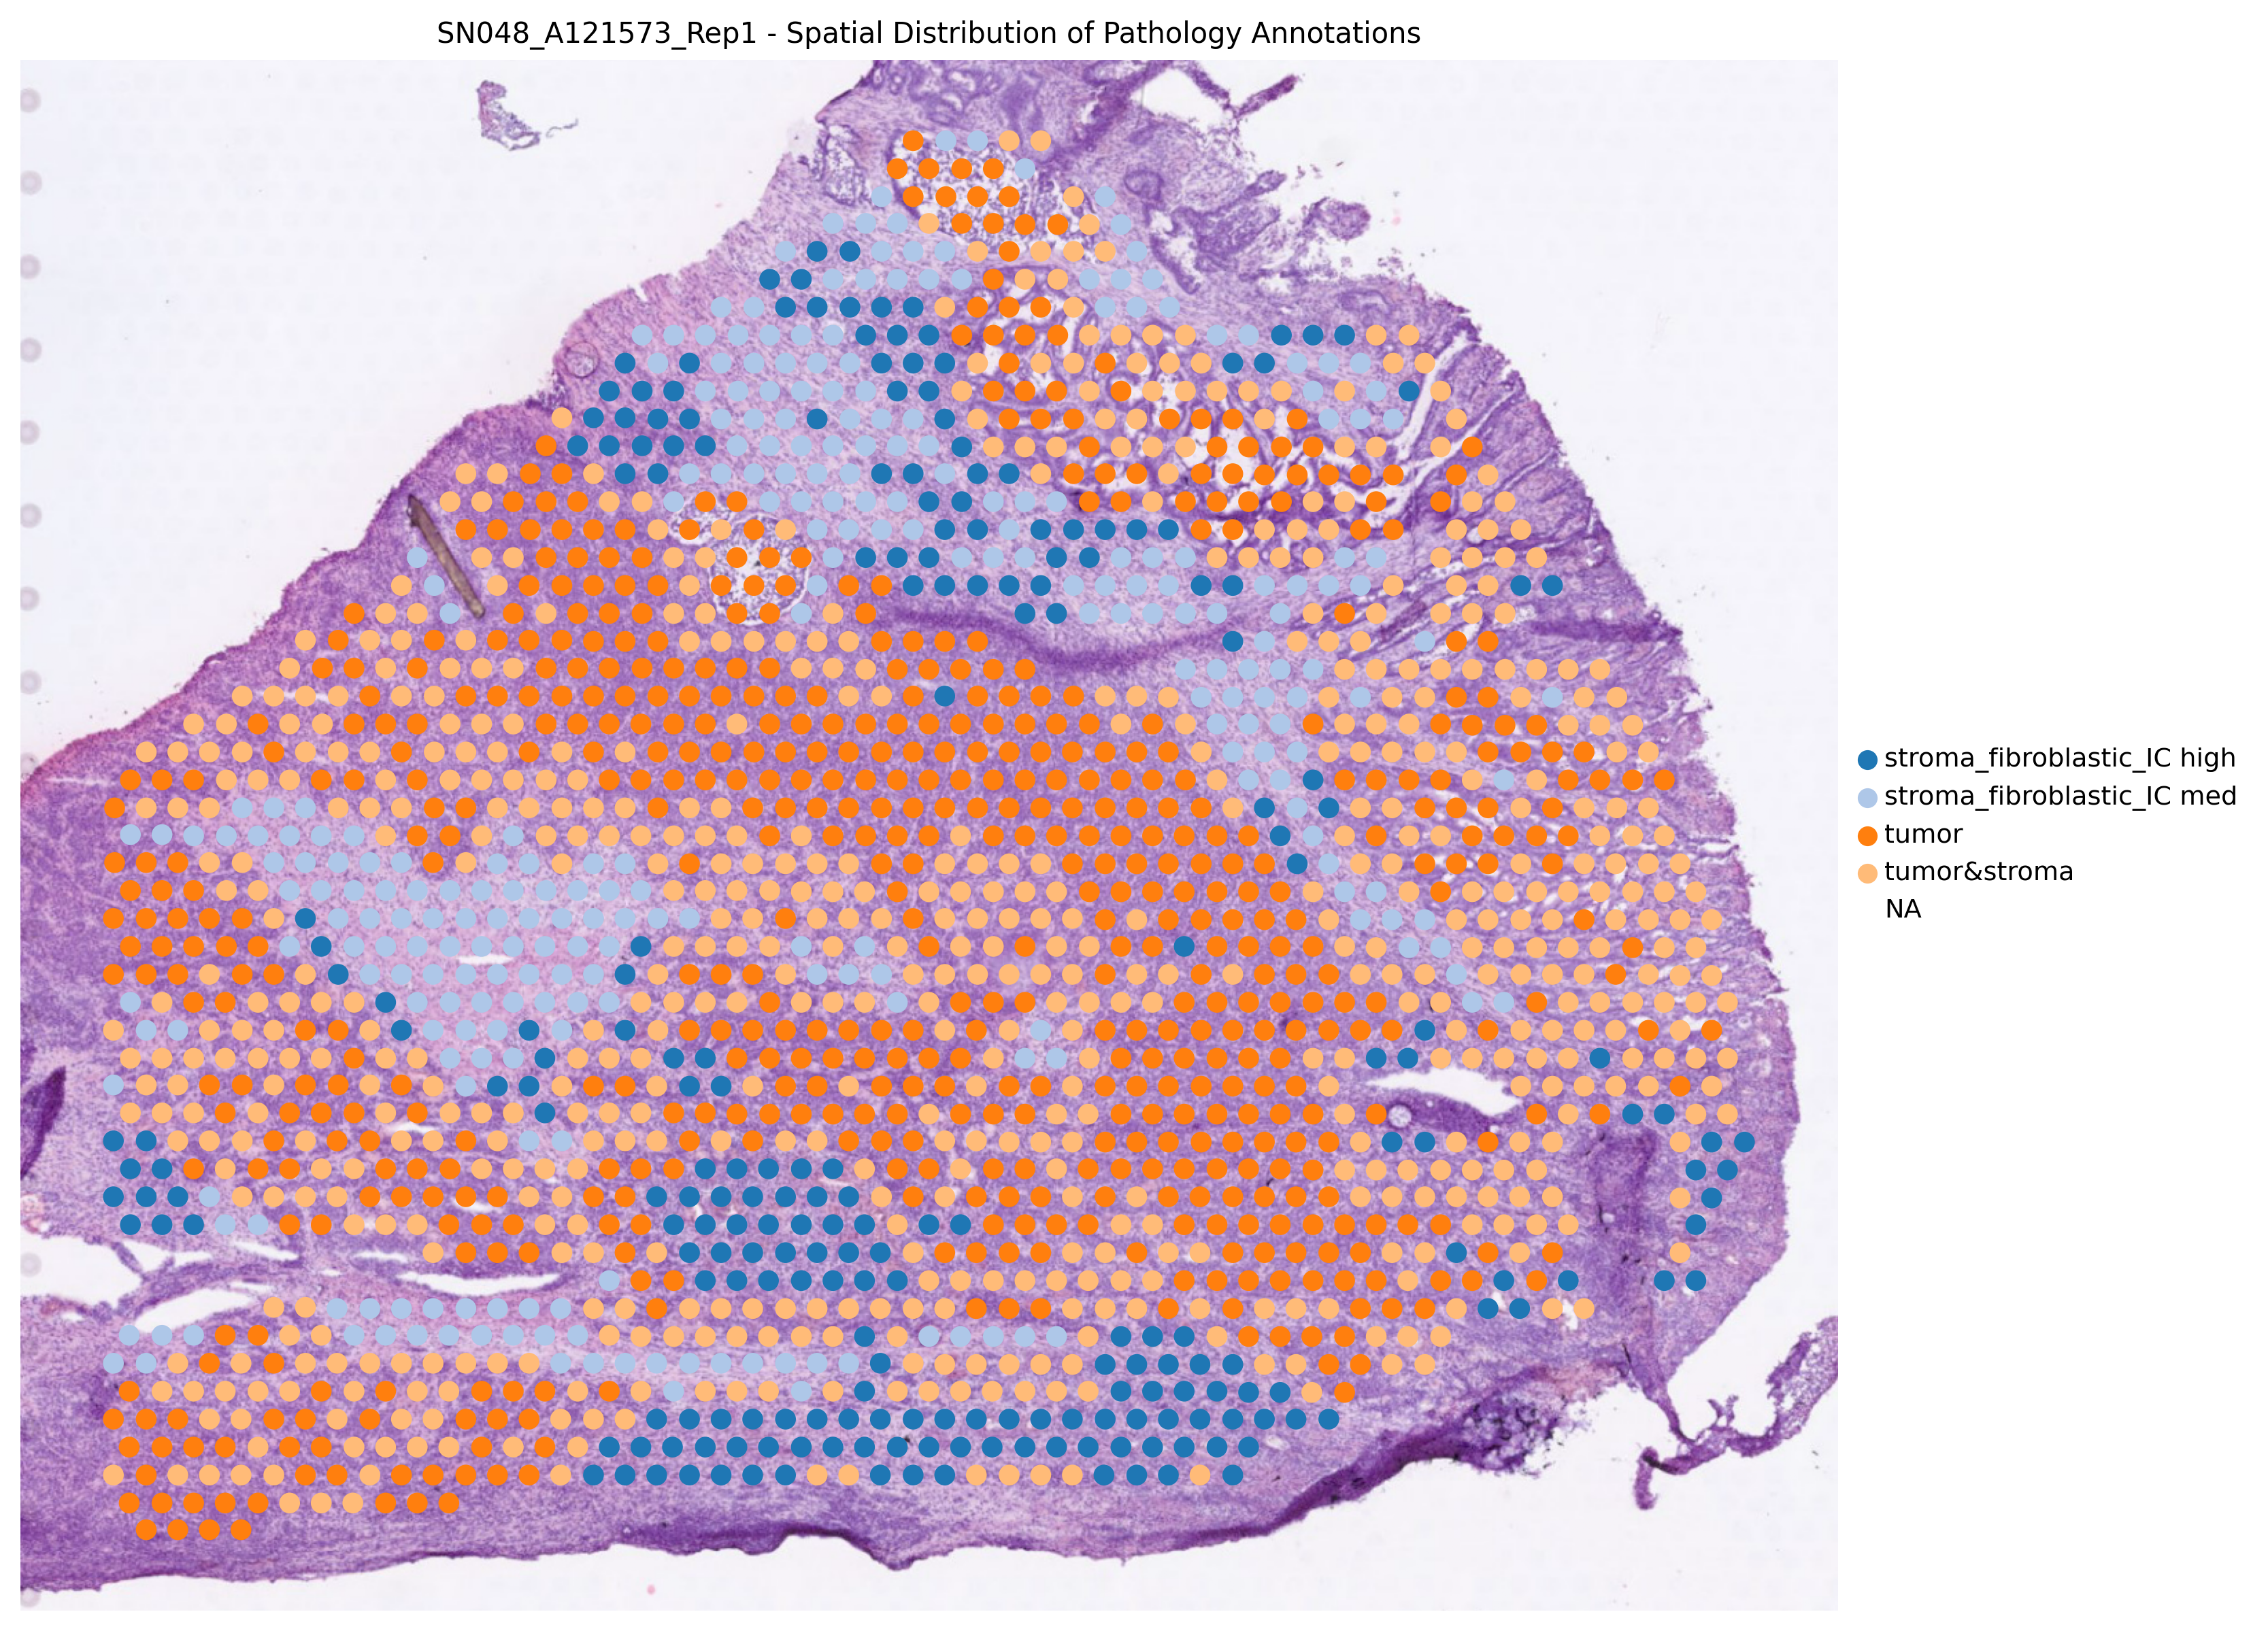


✅ 可视化完成！所有图片保存到当前运行目录，未修改任何原始文件。
📁 生成的图片列表：
   1. Pathology_Annotation_Count_Barplot.png（注释数量条形图）
   2. Pathology_Annotation_Proportion_Pie.png（注释占比饼图）
   3. spatial_Pathology_Annotation_Spatial.png（注释空间分布图）


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# --------------------------
# 1. 只读加载数据 + 内存副本操作
# --------------------------
h5ad_path = "/home/zhangjunyi/xiangmu/nichecompass-main/datasets/12_colorectal_cancer_CRC/12_colorectal_cancer_CRC_h5ad/SN048_A416371_Rep2.h5ad"
# 仅读取，不修改原文件
adata = sc.read_h5ad(h5ad_path)
# 生成内存副本，所有操作基于副本
adata_vis = adata[adata.obs["in_tissue"] == 1].copy()

# 可视化样式配置（保证清晰易读）
sc.set_figure_params(figsize=(12, 10), dpi=150, fontsize=10)
plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# --------------------------
# 2. 统计病理注释的数量分布（先了解数据构成）
# --------------------------
print("=== 病理注释类型及数量统计 ===")
annot_count = adata_vis.obs["pathology_annotation"].value_counts(dropna=False)
print(annot_count)

# 图1：病理注释数量条形图（按数量降序）
plt.figure(figsize=(12, 6))
# 只展示数量≥10的类别（避免类别过多杂乱）
top_annot = annot_count[annot_count >= 10].sort_values(ascending=False)
sns.barplot(
    x=top_annot.index, 
    y=top_annot.values,
    palette="viridis"
)
plt.title("SN048_A121573_Rep1 - Pathology Annotation Count (Top Categories)", fontsize=12)
plt.xlabel("Pathology Annotation", fontsize=10)
plt.ylabel("Number of Spots", fontsize=10)
# 旋转x轴标签，避免重叠
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
# 保存到当前目录，不修改原文件
plt.savefig("Pathology_Annotation_Count_Barplot.png", dpi=150, bbox_inches="tight")
plt.close()

# 图2：病理注释占比饼图（仅展示主要类别）
plt.figure(figsize=(10, 10))
# 合并小众类别为"Other"（占比<5%）
annot_percent = annot_count / annot_count.sum() * 100
main_annot = annot_percent[annot_percent >= 5]
other_percent = annot_percent[annot_percent < 5].sum()
if other_percent > 0:
    main_annot["Other (<5%)"] = other_percent

# 绘制饼图
plt.pie(
    main_annot.values,
    labels=main_annot.index,
    autopct="%1.1f%%",  # 显示百分比
    startangle=90,
    colors=sns.color_palette("viridis", len(main_annot)),
    wedgeprops={"edgecolor": "white", "linewidth": 1}
)
plt.title("SN048_A121573_Rep1 - Pathology Annotation Proportion", fontsize=12)
plt.tight_layout()
plt.savefig("Pathology_Annotation_Proportion_Pie.png", dpi=150, bbox_inches="tight")
plt.close()

# --------------------------
# 3. 核心：病理注释的空间分布可视化（空转数据关键）
# --------------------------
# 过滤掉注释为exclude的Spot（可选，聚焦有效注释）
adata_vis_filtered = adata_vis[adata_vis.obs["pathology_annotation"] != "exclude"].copy()

# 图3：病理注释空间分布图（带组织背景）
sc.pl.spatial(
    adata_vis_filtered,
    img_key="hires",  # 高分辨率组织图像背景
    color="pathology_annotation",
    title="SN048_A121573_Rep1 - Spatial Distribution of Pathology Annotations",
    legend_loc="right margin",  # 图例在右侧，避免遮挡组织
    frameon=False,
    size=1,  # Spot点大小，适配分辨率
    # 自定义配色，区分度更高
    palette=sns.color_palette("tab20", n_colors=len(adata_vis_filtered.obs["pathology_annotation"].unique())),
    # 保存到当前目录，文件名清晰
    save="_Pathology_Annotation_Spatial.png"
)

print("\n✅ 可视化完成！所有图片保存到当前运行目录，未修改任何原始文件。")
print("📁 生成的图片列表：")
print("   1. Pathology_Annotation_Count_Barplot.png（注释数量条形图）")
print("   2. Pathology_Annotation_Proportion_Pie.png（注释占比饼图）")
print("   3. spatial_Pathology_Annotation_Spatial.png（注释空间分布图）")